In [18]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("../..") / ".env")

True

In [2]:
log = kairo.read_log("../../data/test.xes",
    case_id = "case:concept:id",
    activity = "concept:activity",
    timestamp = "time:completed",
    event_id = "event:uidd",
    start_timestamp = "begin:timestamp",
    resource = "org:actor",
    event_duration = "event:runtime_min")
log.head()

parsing log, completed traces :: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 2832.71it/s]


,event:id,concept:name,start_timestamp,time:timestamp,event:duration_min,org:resource,case:concept:name,case:amount,case:region
0,e001,Create Order,2026-03-02 08:00:00+00:00,2026-03-02 08:12:00+00:00,12,Anna,C001,1200.5,EU
1,e002,Check Credit,2026-03-02 08:30:00+00:00,2026-03-02 08:50:00+00:00,20,Ben,C001,1200.5,EU
2,e003,Approve Order,2026-03-02 09:15:00+00:00,2026-03-02 09:25:00+00:00,10,Clara,C001,1200.5,EU
3,e004,Ship Goods,2026-03-03 10:00:00+00:00,2026-03-03 10:45:00+00:00,45,Dmitri,C001,1200.5,EU
4,e005,Create Order,2026-03-02 09:05:00+00:00,2026-03-02 09:20:00+00:00,15,Anna,C002,350.0,NA


In [3]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 3,
 'events': 12,
 'activities': 6,
 'resources': 5,
 'start': Timestamp('2026-03-02 08:12:00+0000', tz='UTC'),
 'end': Timestamp('2026-03-05 09:20:00+0000', tz='UTC'),
 'span_minutes': 4388.0,
 'tpt_days_min': 0.08194444444444444,
 'tpt_days_mean': 1.0800925925925926,
 'tpt_days_median': 1.10625,
 'tpt_days_max': 2.0520833333333335,
 'length_min': 3,
 'length_mean': 4.0,
 'length_median': 4.0,
 'length_max': 5,
 'activity_counts': concept:name
 Create Order     3
 Check Credit     3
 Approve Order    2
 Ship Goods       2
 Reject Order     1
 Send Invoice     1
 Name: count, dtype: int64,
 'resource_counts': org:resource
 Anna      3
 Ben       3
 Clara     3
 Dmitri    2
 Emre      1
 Name: count, dtype: int64}

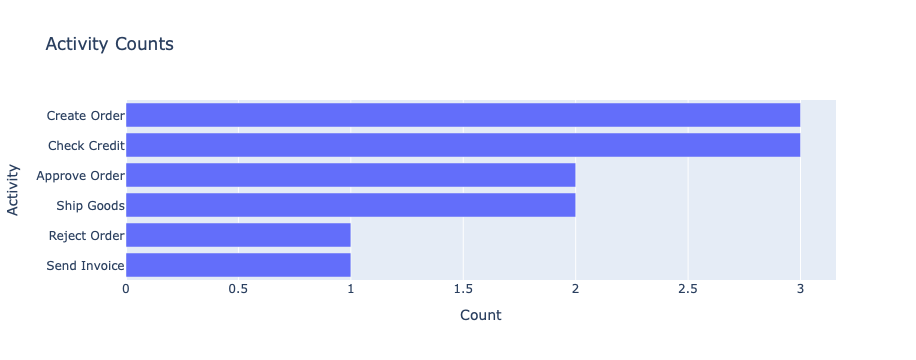

In [4]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [5]:
llm = kairo.LLMConnector(
    provider="anthropic",
    api_key=os.environ["ANTHROPIC_API_KEY"],
    model="claude-haiku-4-5-20251001"
)

response = llm.call(
    prompt="Very briefly analyze this process mining activity distribution. Do not use markdown format, just raw text",
    plots=[activity_plot],
)

response

Message(id='msg_011CfLynu7ngCBzVAUikNHyQ', container=None, content=[TextBlock(citations=None, text="The activity distribution shows a clear hierarchical pattern in process execution frequency. Create Order and Check Credit are the dominant activities, each occurring approximately 2,800-2,900 times, representing the initial stages of the order-to-cash process. Approve Order and Ship Goods are secondary activities with roughly 2,000 occurrences each, indicating a significant filtering point where some orders don't progress further. Reject Order and Send Invoice are the least frequent activities, both around 1,000 occurrences, suggesting relatively low rejection rates and invoice generation only for approved orders. The distribution indicates a healthy process flow with most orders successfully created and credit-checked, though approximately 30-35 percent are either rejected or don't reach the final shipping stage. This pattern is typical of order processing workflows with quality gates 

In [6]:
features = kairo.compute_features_intra(log, sliding_window_size=1)
features

,case:concept:name,time:timestamp,act_freqs:Approve Order,act_freqs:Check Credit,act_freqs:Create Order,act_freqs:Reject Order,act_freqs:Send Invoice,act_freqs:Ship Goods,df_counts:Approve Order -> Ship Goods,df_counts:Check Credit -> Approve Order,...,current_act:Create Order,current_act:Reject Order,current_act:Send Invoice,current_act:Ship Goods,past_acts_1:Approve Order,past_acts_1:Check Credit,past_acts_1:Create Order,past_acts_1:Reject Order,past_acts_1:Send Invoice,past_acts_1:Ship Goods
0,C001,2026-03-02 08:12:00+00:00,0.000000,0.000000,1.000000,0.000000,0.0,0.00,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C001,2026-03-02 08:50:00+00:00,0.000000,0.500000,0.500000,0.000000,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,C001,2026-03-02 09:25:00+00:00,0.333333,0.333333,0.333333,0.000000,0.0,0.00,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,C001,2026-03-03 10:45:00+00:00,0.250000,0.250000,0.250000,0.000000,0.0,0.25,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,C002,2026-03-02 09:20:00+00:00,0.000000,0.000000,1.000000,0.000000,0.0,0.00,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,C002,2026-03-02 10:25:00+00:00,0.000000,0.500000,0.500000,0.000000,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,C002,2026-03-02 11:18:00+00:00,0.000000,0.333333,0.333333,0.333333,0.0,0.00,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,C003,2026-03-03 08:05:00+00:00,0.000000,0.000000,1.000000,0.000000,0.0,0.00,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,C003,2026-03-03 08:55:00+00:00,0.000000,0.500000,0.500000,0.000000,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,C003,2026-03-03 09:42:00+00:00,0.333333,0.333333,0.333333,0.000000,0.0,0.00,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [7]:
std_features = kairo.standardize(features, method="minmax")
std_features

,case:concept:name,time:timestamp,act_freqs:Approve Order,act_freqs:Check Credit,act_freqs:Create Order,act_freqs:Reject Order,act_freqs:Send Invoice,act_freqs:Ship Goods,df_counts:Approve Order -> Ship Goods,df_counts:Check Credit -> Approve Order,...,current_act:Create Order,current_act:Reject Order,current_act:Send Invoice,current_act:Ship Goods,past_acts_1:Approve Order,past_acts_1:Check Credit,past_acts_1:Create Order,past_acts_1:Reject Order,past_acts_1:Send Invoice,past_acts_1:Ship Goods
0,C001,2026-03-02 08:12:00+00:00,0.00,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C001,2026-03-02 08:50:00+00:00,0.00,1.000000,0.375000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,C001,2026-03-02 09:25:00+00:00,1.00,0.666667,0.166667,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,C001,2026-03-03 10:45:00+00:00,0.75,0.500000,0.062500,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,C002,2026-03-02 09:20:00+00:00,0.00,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,C002,2026-03-02 10:25:00+00:00,0.00,1.000000,0.375000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,C002,2026-03-02 11:18:00+00:00,0.00,0.666667,0.166667,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7,C003,2026-03-03 08:05:00+00:00,0.00,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,C003,2026-03-03 08:55:00+00:00,0.00,1.000000,0.375000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,C003,2026-03-03 09:42:00+00:00,1.00,0.666667,0.166667,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


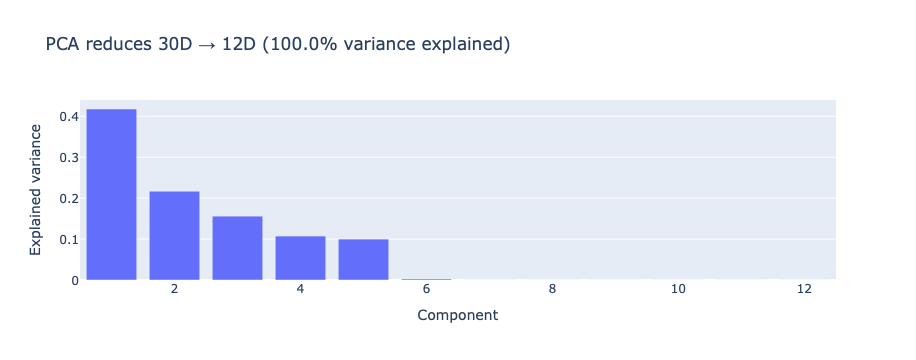

In [8]:
pca = kairo.compute_pca(std_features)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [9]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=5)
compressed_features

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5
0,C001,2026-03-02 08:12:00+00:00,-1.476073,-1.156756,0.125798,-0.020526,-0.014442
1,C001,2026-03-02 08:50:00+00:00,-0.720085,1.072764,-0.817196,-0.212315,-0.154995
2,C001,2026-03-02 09:25:00+00:00,0.732297,0.486218,1.313696,-0.546888,-0.519547
3,C001,2026-03-03 10:45:00+00:00,1.835497,-0.539825,-0.447712,-0.433771,0.826922
4,C002,2026-03-02 09:20:00+00:00,-1.452371,-1.145883,0.128177,0.001057,-0.001930
5,C002,2026-03-02 10:25:00+00:00,-0.672680,1.094512,-0.812437,-0.169150,-0.129971
6,C002,2026-03-02 11:18:00+00:00,-0.334782,1.008466,0.947220,1.424064,1.110495
7,C003,2026-03-03 08:05:00+00:00,-1.490294,-1.163281,0.124370,-0.033475,-0.021949
8,C003,2026-03-03 08:55:00+00:00,-0.748527,1.059716,-0.820051,-0.238213,-0.170009
9,C003,2026-03-03 09:42:00+00:00,0.689633,0.466645,1.309413,-0.585736,-0.542068


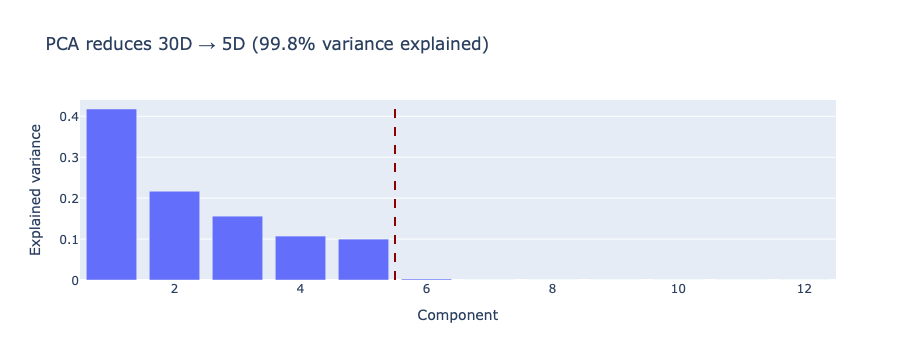

In [10]:
pca_plot = kairo.plot_pca_variances(pca, cut_component=5)
pca_plot.show()

In [23]:
som = kairo.compute_som(compressed_features, size=(3,3))
clusters = kairo.get_som_winners(compressed_features, som)
df = pd.concat([compressed_features, clusters], axis=1)
df

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,i,j
0,C001,2026-03-02 08:12:00+00:00,-1.476073,-1.156756,0.125798,-0.020526,-0.014442,0,0
1,C001,2026-03-02 08:50:00+00:00,-0.720085,1.072764,-0.817196,-0.212315,-0.154995,2,0
2,C001,2026-03-02 09:25:00+00:00,0.732297,0.486218,1.313696,-0.546888,-0.519547,0,2
3,C001,2026-03-03 10:45:00+00:00,1.835497,-0.539825,-0.447712,-0.433771,0.826922,2,2
4,C002,2026-03-02 09:20:00+00:00,-1.452371,-1.145883,0.128177,0.001057,-0.001930,0,0
5,C002,2026-03-02 10:25:00+00:00,-0.672680,1.094512,-0.812437,-0.169150,-0.129971,2,0
6,C002,2026-03-02 11:18:00+00:00,-0.334782,1.008466,0.947220,1.424064,1.110495,2,1
7,C003,2026-03-03 08:05:00+00:00,-1.490294,-1.163281,0.124370,-0.033475,-0.021949,0,0
8,C003,2026-03-03 08:55:00+00:00,-0.748527,1.059716,-0.820051,-0.238213,-0.170009,2,0
9,C003,2026-03-03 09:42:00+00:00,0.689633,0.466645,1.309413,-0.585736,-0.542068,0,2


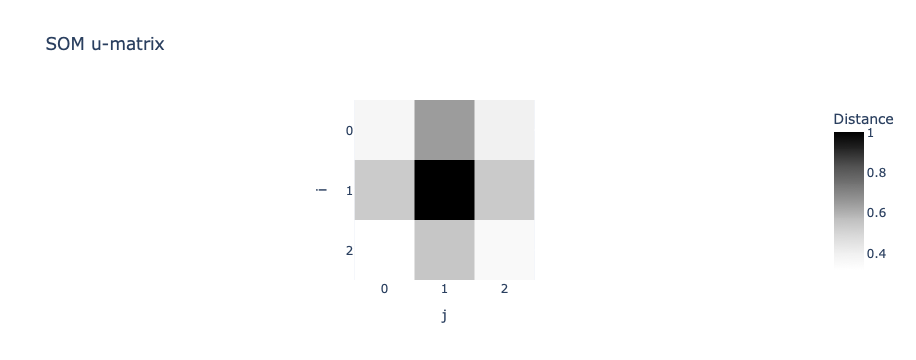

In [12]:
u_matrix = kairo.plot_som_u_matrix(som)
u_matrix.show()

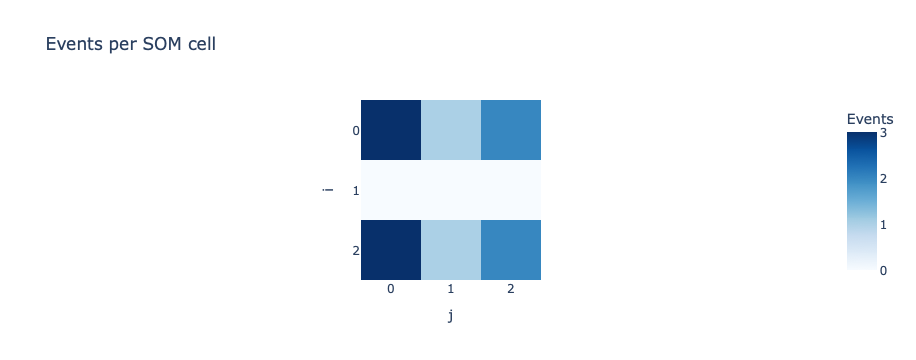

In [26]:
heatmap = kairo.plot_som_heatmap(clusters, som)
heatmap.show()

In [34]:
color_mapping = kairo.compute_som_color_mapping((3,3))

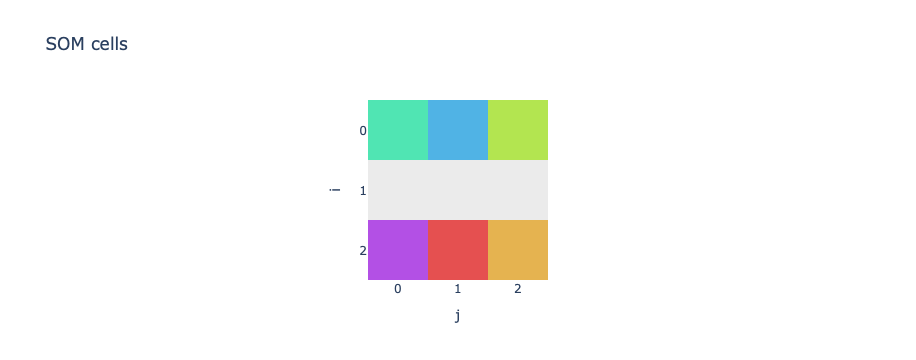

In [35]:
som_colors = kairo.plot_som_colors(df, color_mapping)
som_colors.show()